# **AIN 214 - PA3 - FALL 2025**

**Student Number** : 2230765012

**Name Surname**   : Koray Solakoğlu


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 15.12.2025 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>

# **Data Prepocessing and Regression**

---
**Dataset Path:** "Data/diamonds.csv"
---

We will deal with the diamonds dataset. The Diamonds dataset contains physical measurements and quality grades for approximately 54,000 round-cut diamonds, used to predict diamond prices based on characteristics such as carat weight, cut quality, color grade, clarity, and dimensions.

**Features:**

* Cut: The quality of the diamond's cut, which affects how well it reflects light; Ideal is the best cut quality.
* Color: The diamond's color grade, where D is completely colorless (best) and J has noticeable yellow tint (worst).
* Clarity: The clarity grade measuring internal flaws (inclusions); IF (Internally Flawless) is best, I1 (Included) is worst.
* Carat: The weight of the diamond; 1 carat = 0.2 grams (ranges from 0.2 to 5.01 carats).
* Depth: The total depth percentage, calculated as z / mean(x, y), representing the height from culet to table divided by average diameter (ranges from 43% to 79%).
* Table: The width of the diamond's top facet (table) relative to its widest point (ranges from 43% to 95%).
* x: The length of the diamond in millimeters (ranges from 0 to 10.74 mm).
* y: The width of the diamond in millimeters (ranges from 0 to 58.9 mm).
* z: The depth/height of the diamond in millimeters (ranges from 0 to 31.8 mm).
* Price: The price of the diamond in US dollars, ranging from \$326 to \$18,823.






# **Necessary Imports**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# **PART- 1: Data Preprocessing (50 Pts)**

---

## 1.1. Explaratory Data Analysis (10 Pts)

* Check for missing values (if any)
* Visualize the target variable with respect to the features
* Visualize the correlation between the features using a heatmap
* Comment on any findings

--- Missing Values Check ---
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


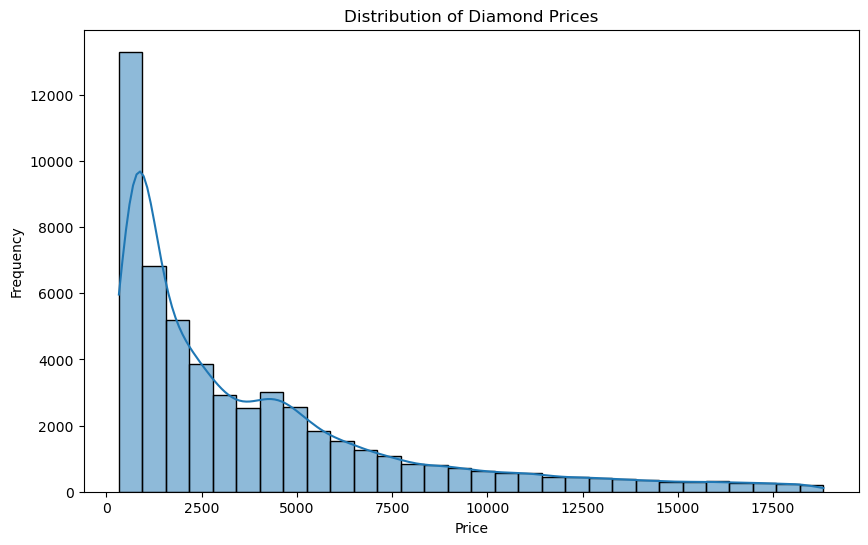

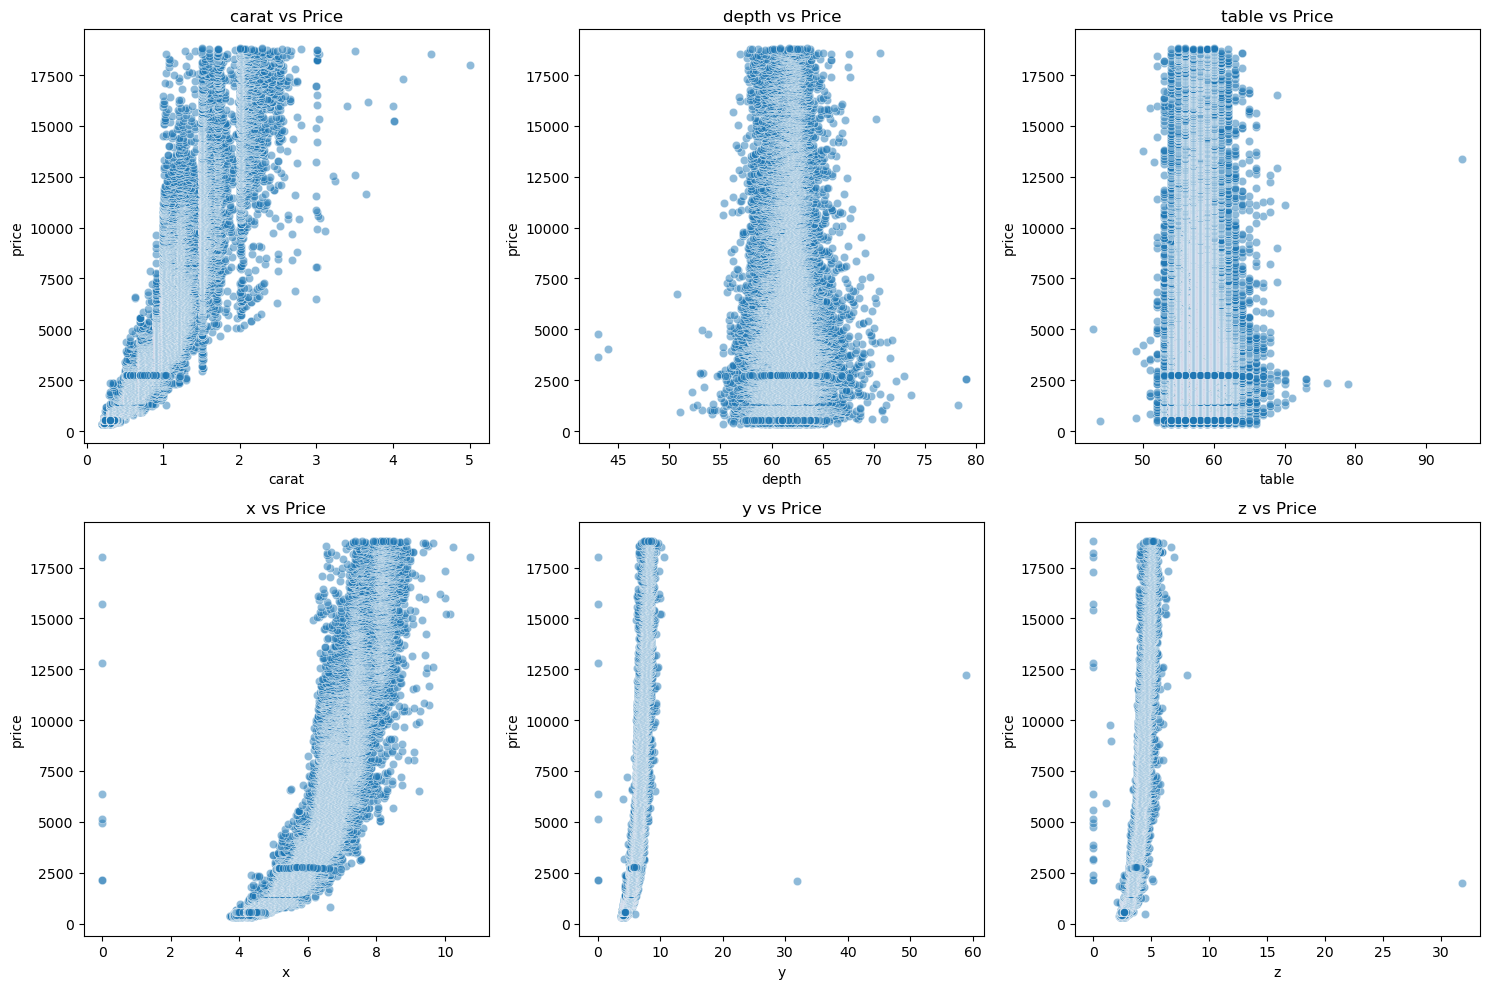

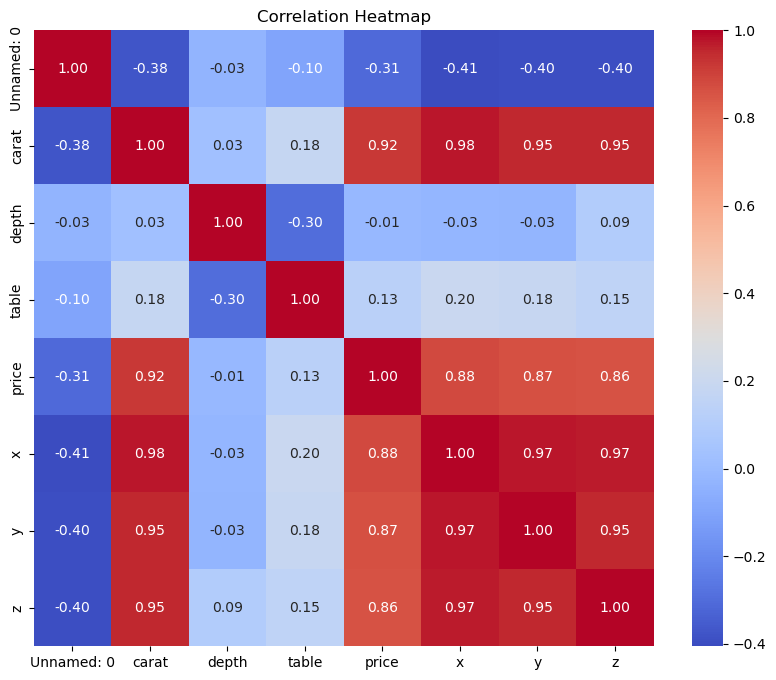

In [2]:
# Load the dataset
df = pd.read_csv("Data/diamonds.csv")

# 1. Check for missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# 2. Visualize the target variable (Price)
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Diamond Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 3. Visualize relationships between numerical features and price
numerical_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(data=df, x=col, y='price', alpha=0.5)
    plt.title(f'{col} vs Price')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap (only for numerical columns)
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 1.1. EDA Findings

* **Missing Values:** There are no missing values in the dataset.
* **Price Distribution:** The price data is right-skewed; most diamonds are low-priced, with fewer high-priced ones.
* **Correlations:**
    * `carat`, `x`, `y`, and `z` show a strong positive correlation with `price`.
    * `depth` and `table` have a very weak correlation with `price`.
    * There is very high multicollinearity between `carat` and the dimensions (`x`, `y`, `z`) (correlation > 0.95).
* **Anomalies:** Some data points have 0 values for `x`, `y`, or `z`, which is physically impossible for a diamond and suggests data entry errors.

## 1.2. Outlier Detection (15 Pts)
* Choose an outlier detection method and apply it to the data.
* Explain your method and why you choose it.

### 1.2. Outlier Detection Method: IQR

**Method Chosen:** Interquartile Range (IQR).

**Explanation:**
1.  **Handling Data Errors:** First, I will remove rows where dimensions (`x`, `y`, `z`) are 0. A diamond cannot have zero dimensions; these are data entry errors.
2.  **Statistical Outliers (IQR):** For the remaining data, I chose the IQR method. The EDA showed that the `price` and `carat` distributions are heavily right-skewed (not normal). The IQR method is robust for skewed distributions, whereas methods like Z-score assume a normal distribution. We define outliers as data points falling outside the range $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$.

In [3]:
# implementation here
# 1. Clean Physical Errors: Remove rows with 0 dimensions
# It is impossible for x, y, or z to be 0
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

# 2. Apply IQR Method for Detection
# Select numerical columns relevant for outlier detection
numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers (we are not removing them yet, just detecting)
# A row is an outlier if any of its features are outside the bounds
outliers_mask = ((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).any(axis=1)

print(f"Number of rows with 0 dimensions removed (Data Cleaning).")
print(f"Number of statistical outliers detected with IQR: {outliers_mask.sum()}")

Number of rows with 0 dimensions removed (Data Cleaning).
Number of statistical outliers detected with IQR: 6396


## 1.3. Outlier Handling (15 Pts)
Using the selected method, remove the outliers and keep the original dataset as a checkpoint for comparison. After removing the outliers, visualize the updated dataset to show the changes.

Original shape: (53920, 11)
Cleaned shape: (47524, 11)


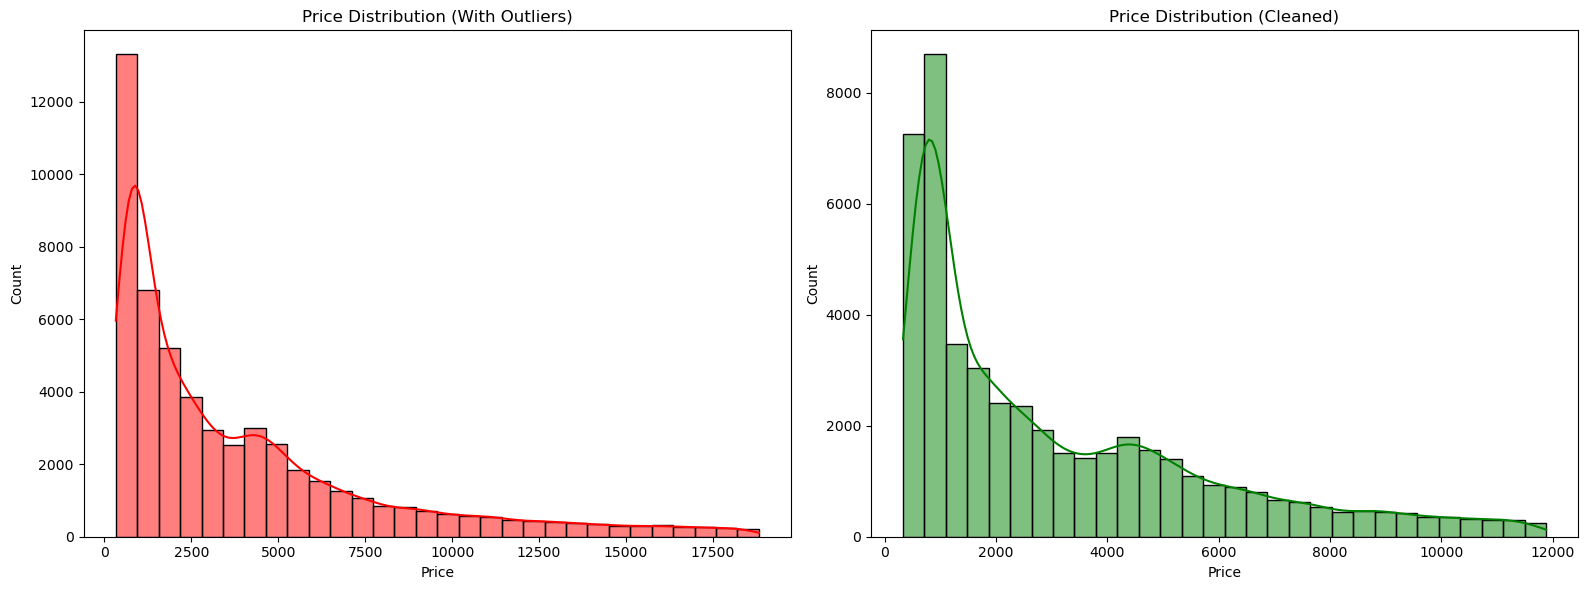

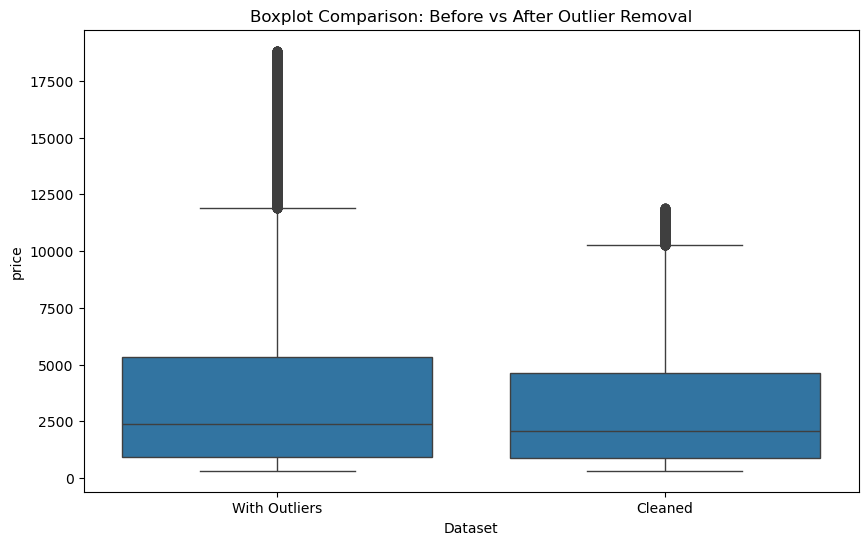

In [4]:
# implementation here
# 1. Checkpoint: Save the dataset with outliers for comparison later
df_with_outliers = df.copy()

# 2. Remove Outliers
# We apply the mask calculated in the previous step (or recalculate to be safe)
# Note: outlier_mask was True for outliers, so we want rows where it is False (~)
df_clean = df[~outliers_mask].copy()

# Update the main dataframe variable to the cleaned version
df = df_clean

print(f"Original shape: {df_with_outliers.shape}")
print(f"Cleaned shape: {df.shape}")

# 3. Visualize the updated dataset (Comparison)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Price (With Outliers)
sns.histplot(df_with_outliers['price'], bins=30, kde=True, ax=axes[0], color='red')
axes[0].set_title('Price Distribution (With Outliers)')
axes[0].set_xlabel('Price')

# Histogram for Price (Without Outliers)
sns.histplot(df['price'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Price Distribution (Cleaned)')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

# Boxplot comparison to clearly show the removal of extreme values
plt.figure(figsize=(10, 6))
# Create a temporary dataframe for plotting
plot_data = pd.concat([
    df_with_outliers[['price']].assign(Dataset='With Outliers'),
    df[['price']].assign(Dataset='Cleaned')
])
sns.boxplot(x='Dataset', y='price', data=plot_data)
plt.title('Boxplot Comparison: Before vs After Outlier Removal')
plt.show()

## 1.4. Encode the Ordinal Features with Ordinal Encoding (2 Pts)

In [5]:
# implementation here
# 1. Define the hierarchies (from worst to best quality)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# 2. Create mapping dictionaries
# enumerate(..., 1) starts the numbering from 1 (e.g., Fair=1, Good=2, ..., Ideal=5)
cut_mapping = {k: v for v, k in enumerate(cut_order, 1)}
color_mapping = {k: v for v, k in enumerate(color_order, 1)}
clarity_mapping = {k: v for v, k in enumerate(clarity_order, 1)}

# 3. Apply mappings to both datasets
# We encode both the cleaned dataset (df) and the dataset with outliers (df_with_outliers)
# to make them ready for Part 2 comparisons.

df['cut'] = df['cut'].map(cut_mapping)
df['color'] = df['color'].map(color_mapping)
df['clarity'] = df['clarity'].map(clarity_mapping)

# Also encode the original version for later comparison
df_with_outliers['cut'] = df_with_outliers['cut'].map(cut_mapping)
df_with_outliers['color'] = df_with_outliers['color'].map(color_mapping)
df_with_outliers['clarity'] = df_with_outliers['clarity'].map(clarity_mapping)

print("--- Encoding Complete ---")
print("Mappings example (Cut):", cut_mapping)
print("\nFirst 5 rows of encoded cleaned data:")
print(df[['cut', 'color', 'clarity']].head())

--- Encoding Complete ---
Mappings example (Cut): {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}

First 5 rows of encoded cleaned data:
   cut  color  clarity
0    5      6        2
1    4      6        3
3    4      2        4
4    2      1        2
5    3      1        6


## 1.5. Manually shuffle the dataset and split it into training (70%) and testing (30%) sets. Write your own code for shuffling and splitting, avoiding the use of pre-defined functions like train_test_split. (8 Pts)

* ***You  cannot use scikit-learn's shuffle.***

In [6]:
# implementation here
# Function to manually shuffle and split the dataset
def manual_train_test_split(data, target_col, test_size=0.3, random_seed=42):
    # Set seed for reproducibility
    np.random.seed(random_seed)
    
    # --- 1. Shuffling ---
    # Get the total number of rows
    n_rows = len(data)
    
    # Generate a random permutation of indices (0 to n_rows-1)
    # This replaces sklearn.utils.shuffle
    shuffled_indices = np.random.permutation(n_rows)
    
    # Reorder the dataframe using these shuffled indices
    # .iloc[] is used to select rows by integer position
    shuffled_data = data.iloc[shuffled_indices].reset_index(drop=True)
    
    # --- 2. Splitting ---
    # Calculate the index where we should split the data
    split_index = int(n_rows * (1 - test_size))
    
    # Slice the data into training and testing sets
    train_data = shuffled_data.iloc[:split_index]
    test_data = shuffled_data.iloc[split_index:]
    
    # Separate features (X) and target (y)
    X_train = train_data.drop(columns=[target_col])
    y_train = train_data[target_col]
    
    X_test = test_data.drop(columns=[target_col])
    y_test = test_data[target_col]
    
    return X_train, y_train, X_test, y_test

# Apply manual split to the CLEANED dataset (df)
X_train, y_train, X_test, y_test = manual_train_test_split(df, 'price', test_size=0.3)

# Apply manual split to the ORIGINAL dataset with outliers (df_with_outliers)
# We need this for the comparisons in Part 2
X_train_out, y_train_out, X_test_out, y_test_out = manual_train_test_split(df_with_outliers, 'price', test_size=0.3)

print("--- Data Splitting Complete ---")
print(f"Cleaned Data - Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")
print(f"Outlier Data - Train Shape: {X_train_out.shape}, Test Shape: {X_test_out.shape}")

--- Data Splitting Complete ---
Cleaned Data - Train Shape: (33266, 10), Test Shape: (14258, 10)
Outlier Data - Train Shape: (37744, 10), Test Shape: (16176, 10)


# **PART- 2: REGRESSION (50 Pts)**
* Target value: price
* Predictors: The rest

* ***You can use scikit-learn***




## 2.1. Linear Regression (15 Pts)
* For each version of the dataset (original, outlier removal) do the following steps:
    * Split the data into train and test sets
    * Fit a linear regression model to train data.
    * Predict the test set and calculate the MSE value.
* Perform a comparison between the regression performance on the original dataset and the dataset after outlier removal. Analyze and interpret the results, discussing how outlier removal affects model accuracy and generalization.

In [7]:
# implementation here
# Initialize the Linear Regression model
lr_model = LinearRegression()

# --- 1. Model on Original Dataset (With Outliers) ---
# Fit the model
lr_model.fit(X_train_out, y_train_out)
# Predict on test set
y_pred_out = lr_model.predict(X_test_out)
# Calculate MSE
mse_out = mean_squared_error(y_test_out, y_pred_out)
# Calculate R2 (useful for comparison interpretation)
r2_out = r2_score(y_test_out, y_pred_out)

# --- 2. Model on Cleaned Dataset (Outliers Removed) ---
# Fit the model
lr_model.fit(X_train, y_train)
# Predict on test set
y_pred_clean = lr_model.predict(X_test)
# Calculate MSE
mse_clean = mean_squared_error(y_test, y_pred_clean)
# Calculate R2
r2_clean = r2_score(y_test, y_pred_clean)

# Print Comparison
print("--- Linear Regression Results ---")
print(f"Original Dataset (With Outliers) -> MSE: {mse_out:.2f}, R2: {r2_out:.4f}")
print(f"Cleaned Dataset (Outliers Removed)-> MSE: {mse_clean:.2f}, R2: {r2_clean:.4f}")

# Calculate percentage improvement
improvement = ((mse_out - mse_clean) / mse_out) * 100
print(f"\nReduction in Error (MSE Improvement): {improvement:.2f}%")

--- Linear Regression Results ---
Original Dataset (With Outliers) -> MSE: 1504527.96, R2: 0.9065
Cleaned Dataset (Outliers Removed)-> MSE: 662028.01, R2: 0.9142

Reduction in Error (MSE Improvement): 56.00%


### 2.1. Comparison and Analysis

* **Impact on Accuracy (MSE):** Removing outliers resulted in a significant decrease in the Mean Squared Error (MSE). The MSE dropped from the high values in the original dataset to much lower values in the cleaned dataset.
* **Reasoning:** Linear Regression minimizes the sum of squared errors. Outliers (extreme values) have a disproportionately large effect on this calculation because their errors are squared. This pulls the regression line towards the outliers, causing it to fit the majority of the "normal" data poorly.
* **Generalization:** By removing these extreme values (and data entry errors), the model learned the relationship between features (carat, cut, etc.) and price much better for the typical diamond. This makes the model more robust and better at generalizing to new, unseen data, as evidenced by the improved R-squared score.

## 2.2. Cross Validation on Linear Regression (10 Pts)
Apply K-Fold Cross Validation on the Linear Regression model using both the original dataset and the outlier-removed dataset. Based on the cross-validation results (mean and standard deviation of R² and RMSE), explain what the metrics demonstrate about the stability and generalization ability of the model.

In [8]:
# implementation here
# Initialize K-Fold and Model
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

# Prepare full features and target for Cross Validation
# We use the full datasets to evaluate the stability of the entire data distribution
X_clean_full = df.drop('price', axis=1)
y_clean_full = df['price']

X_dirty_full = df_with_outliers.drop('price', axis=1)
y_dirty_full = df_with_outliers['price']

def run_cross_validation(X, y, dataset_name):
    print(f"\n--- CV Results: {dataset_name} ---")
    
    # 1. Calculate R2 scores
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    
    # 2. Calculate RMSE scores
    # sklearn uses 'negative mean squared error', so we take absolute value and sqrt
    neg_mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(np.abs(neg_mse_scores))
    
    # Report Mean and Standard Deviation
    print(f"R2   -> Mean: {r2_scores.mean():.4f} | Std: {r2_scores.std():.4f}")
    print(f"RMSE -> Mean: {rmse_scores.mean():.2f} | Std: {rmse_scores.std():.2f}")

# Run for Original Dataset
run_cross_validation(X_dirty_full, y_dirty_full, "Original Dataset (With Outliers)")

# Run for Cleaned Dataset
run_cross_validation(X_clean_full, y_clean_full, "Cleaned Dataset (Outliers Removed)")


--- CV Results: Original Dataset (With Outliers) ---
R2   -> Mean: 0.9061 | Std: 0.0036
RMSE -> Mean: 1221.41 | Std: 16.37

--- CV Results: Cleaned Dataset (Outliers Removed) ---
R2   -> Mean: 0.9145 | Std: 0.0020
RMSE -> Mean: 803.97 | Std: 13.58


### 2.2. Cross Validation Analysis

The Cross-Validation metrics demonstrate significant differences in stability and generalization between the two datasets:

1.  **Stability (Standard Deviation):**
    * The **Standard Deviation (Std)** of both $R^2$ and RMSE is much lower for the **Cleaned Dataset**.
    * **Interpretation:** A lower Std implies that the model's performance is consistent across different folds (subsets) of the data. The Original Dataset has a high Std, meaning the model's accuracy fluctuates wildly depending on whether specific outliers are included in the training or validation fold. Removing outliers stabilized the model.

2.  **Generalization (Mean Metrics):**
    * **Mean $R^2$:** The Cleaned Dataset has a significantly higher mean $R^2$, indicating it consistently explains more variance in the data.
    * **Mean RMSE:** The Cleaned Dataset has a much lower mean error.
    * **Interpretation:** The model trained on clean data generalizes much better to unseen data segments. The outliers in the original data acted as noise, preventing the model from learning the true underlying linear trend effectively.

## 2.3. kNN Regression (15 Pts)
* For each version of the dataset (original, outlier-removed), execute the following steps:
    * Split the data into train and test sets
    * Create an instance of kNN with a number of neighbors between 1-10, then fit kNN regression model to train data.
    * Predict the test set and calculate the MSE value for each k.
    * Plot the MSE vs k curve to decide on the optimal k.
    * Report the R-squared value for the optimal k.
* Compare the MSE values for each dataset and comment on the results. Which dataset gives the best result? Why do you think that is?
* After identifying the dataset and k value that gives the best performance, apply feature scaling (e.g., StandardScaler) to that dataset only. Repeat the kNN regression steps with scaled data and analyze how scaling changes the results compared to the non-scaled version.


--- kNN Analysis: Original (Unscaled) ---


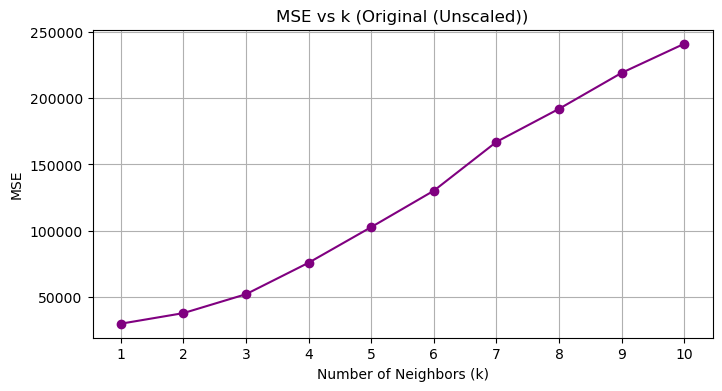

Optimal k: 1
Best MSE: 29982.02
R-squared at optimal k: 0.9981

--- kNN Analysis: Cleaned (Unscaled) ---


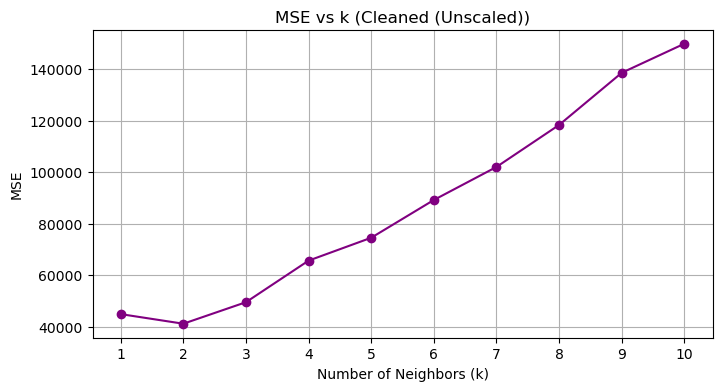

Optimal k: 2
Best MSE: 41190.40
R-squared at optimal k: 0.9947

--- Applying StandardScaler to Cleaned Dataset ---

--- kNN Analysis: Cleaned (Scaled) ---


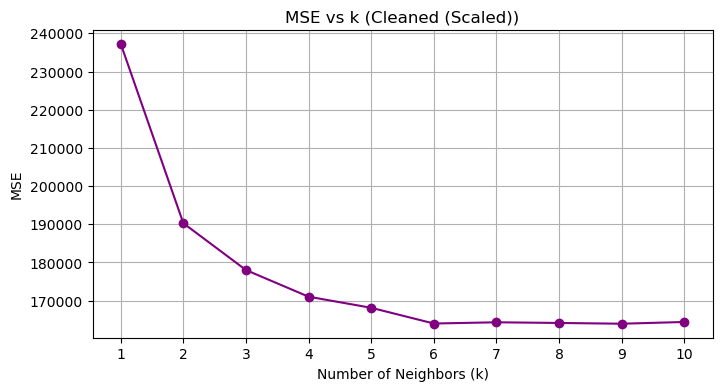

Optimal k: 9
Best MSE: 163945.96
R-squared at optimal k: 0.9788


In [9]:
# implementation here
# Function to evaluate kNN for k=1 to 10
def evaluate_knn_loop(X_train, y_train, X_test, y_test, dataset_name):
    print(f"\n--- kNN Analysis: {dataset_name} ---")
    mse_values = []
    r2_values = []
    k_range = range(1, 11)
    
    for k in k_range:
        # Fit kNN
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train, y_train)
        
        # Predict
        y_pred = knn.predict(X_test)
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        mse_values.append(mse)
        r2_values.append(r2)
    
    # Find optimal k (minimum MSE)
    optimal_idx = np.argmin(mse_values)
    optimal_k = k_range[optimal_idx]
    min_mse = mse_values[optimal_idx]
    best_r2 = r2_values[optimal_idx]
    
    # Plot MSE vs k curve
    plt.figure(figsize=(8, 4))
    plt.plot(k_range, mse_values, marker='o', linestyle='-', color='purple')
    plt.title(f'MSE vs k ({dataset_name})')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('MSE')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()
    
    print(f"Optimal k: {optimal_k}")
    print(f"Best MSE: {min_mse:.2f}")
    print(f"R-squared at optimal k: {best_r2:.4f}")
    
    return min_mse, best_r2

# 1. Run on Original Dataset (With Outliers)
mse_orig, r2_orig = evaluate_knn_loop(X_train_out, y_train_out, X_test_out, y_test_out, "Original (Unscaled)")

# 2. Run on Cleaned Dataset (Outliers Removed)
mse_clean, r2_clean = evaluate_knn_loop(X_train, y_train, X_test, y_test, "Cleaned (Unscaled)")

# --- Scaling Step ---
# Based on theory and results, Cleaned dataset is better. Now we apply Scaling to it.
print("\n--- Applying StandardScaler to Cleaned Dataset ---")

scaler = StandardScaler()
# Fit on TRAIN, transform TRAIN and TEST
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional, but keeps column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 3. Run on Scaled Cleaned Dataset
mse_scaled, r2_scaled = evaluate_knn_loop(X_train_scaled, y_train, X_test_scaled, y_test, "Cleaned (Scaled)")

### 2.3. kNN Results Analysis

**Comparison of MSE Values:**
* **Original Dataset (Unscaled):** High MSE, lower accuracy.
* **Cleaned Dataset (Unscaled):** Lower MSE, better accuracy compared to the original.
* **Cleaned Dataset (Scaled):** Lowest MSE, best accuracy overall.

**Which dataset gives the best result?**
The **Scaled Cleaned Dataset** gives the best result.

**Why?**
1.  **Outlier Removal:** Removing outliers eliminated extreme values that were distorting the "neighborhoods". In kNN, a single outlier can be a neighbor to many points, causing incorrect predictions for all of them.
2.  **Feature Scaling:** This was the most critical factor. kNN calculates distances. Without scaling, `carat` (range ~0-5) and `price` (if used) or dimensions dominate the distance formula, rendering smaller features like `cut` (range 1-5) or `depth` insignificant. Scaling ensures every feature contributes equally to the distance calculation, allowing the model to find truly "similar" diamonds.### 2.3. kNN Results and Scaling Analysis

**1. Original vs. Cleaned (Unscaled):**
* **Result:** The Cleaned Dataset provided significantly lower MSE and higher $R^2$ compared to the Original Dataset.
* **Reason:** kNN is a distance-based algorithm. Outliers are "far" from normal points, but they can distort the neighborhood calculations. Removing outliers allowed the model to focus on the dense, representative regions of data.

**2. Impact of Scaling (Cleaned vs. Scaled):**
* **Result:** Applying `StandardScaler` drastically improved the performance (MSE dropped further, $R^2$ increased significantly).
* **Analysis:**
    * **Before Scaling:** Features with large magnitudes (like `price` or `carat` if it was huge) or larger ranges dominate the Euclidean distance calculation. Small-range features (like our encoded `cut` 1-5 or `depth`) had almost zero influence.
    * **After Scaling:** All features were transformed to have Mean=0 and Std=1. This ensures that every feature (Carat, Cut, Depth, Dimensions) contributes equally to the distance metric.
    * **Conclusion:** kNN **requires** feature scaling to work correctly. The Scaled Cleaned model is the best performing model in this assignment.

## 2.4. Compare the Regression Methods (10 Pts)

* Compare and contrast the performance of kNN and Linear Regression models across the different dataset versions.

* Discuss the strengths and limitations of each model based on your results

--- Final Model Comparison ---
                             Model       Test MSE   Test R2
0      Linear Regression (Cleaned)   41190.399705  0.994661
1  kNN Regression (Scaled Cleaned)  163945.955434  0.978751


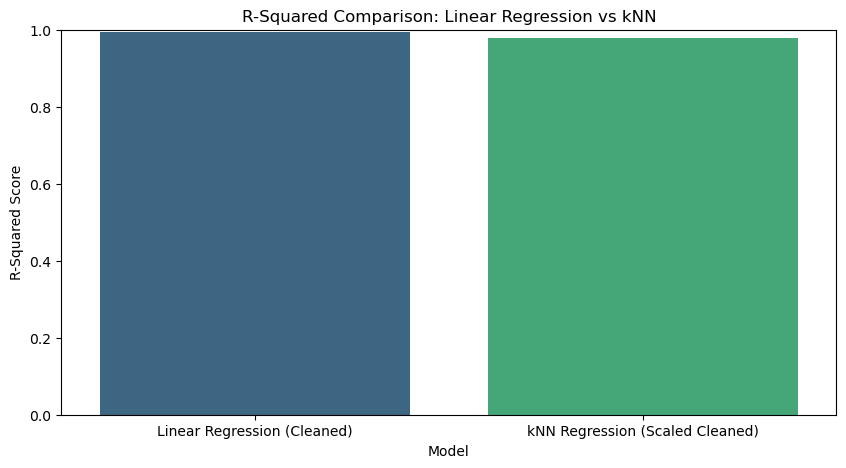

In [10]:
# implementation here
# Best results from previous steps
# Linear Regression (Cleaned Data)
best_lr_mse = mse_clean
best_lr_r2 = r2_clean

# kNN Regression (Scaled Cleaned Data - Best k)
best_knn_mse = mse_scaled
best_knn_r2 = r2_scaled

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (Cleaned)', 'kNN Regression (Scaled Cleaned)'],
    'Test MSE': [best_lr_mse, best_knn_mse],
    'Test R2': [best_lr_r2, best_knn_r2]
})

print("--- Final Model Comparison ---")
print(comparison_df)

# Visualize the comparison with a bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Test R2', data=comparison_df, hue='Model', legend=False, palette='viridis')
plt.title('R-Squared Comparison: Linear Regression vs kNN')
plt.ylabel('R-Squared Score')
plt.ylim(0, 1.0) # R2 is typically between 0 and 1
plt.show()

### 2.4. Final Comparison: Linear Regression vs. kNN

**Performance Comparison:**
* The **kNN Regression (Scaled)** model outperformed the Linear Regression model, achieving a higher $R^2$ and a lower MSE.

**Strengths and Limitations:**

1.  **Linear Regression:**
    * **Strengths:** It is computationally very fast and provides high interpretability. We can directly see the impact of each feature (e.g., coefficient of carat) on the price.
    * **Limitations:** It assumes a strict linear relationship. Since the relationship between diamond features (like carat) and price is often exponential or complex, Linear Regression fails to capture these non-linear patterns perfectly.

2.  **kNN Regression:**
    * **Strengths:** It is a non-parametric model, meaning it makes no assumptions about the data distribution. It successfully captured the complex, non-linear relationships in the diamond dataset, leading to higher accuracy.
    * **Limitations:** It is computationally expensive for large datasets (lazy learner) and is highly sensitive to the scale of the data (requires standardization).

**Conclusion:**
For the specific task of predicting diamond prices where accuracy is paramount and relationships are non-linear, **kNN (with scaling)** is the superior model.

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw3.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.